Part 3: NLP and Sequence Modeling Mini Project

Task 1: Dataset Understanding


In [77]:
import pandas as pd

# Load dataset
df = pd.read_csv(r"C:\Users\sriva\Downloads\ai_project_synthetic_datasets-20260505T144938Z-3-001\ai_project_synthetic_datasets\part_3_nlp_sequence_modeling\customer_support_text_classification.csv")

# Display first 5 rows
print(df.head())

# Display number of records
print("\nNumber of records:", len(df))

  ticket_id channel                                   customer_message  \
0  TKT00001    chat  I need information about the payment process. ...   
1  TKT00002   phone      I need information about the payment process.   
2  TKT00003   email  The refund process was fast and convenient. I ...   
3  TKT00004  social  My refund is still pending and this experience...   
4  TKT00005    chat   Please tell me how to update my account details.   

  sentiment_label  word_count  urgent_flag  
0         neutral          18            1  
1         neutral           7            0  
2        positive          12            0  
3        negative          15            1  
4         neutral           9            0  

Number of records: 1500


In [78]:
# Target classes are in the column named "sentiment_label"
print("Target classes:")
print(df['sentiment_label'].unique())
# Sample text records
print("\nCustomer messages:")
print(df['customer_message'].head(5))

Target classes:
<StringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str

Customer messages:
0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ...
3    My refund is still pending and this experience...
4     Please tell me how to update my account details.
Name: customer_message, dtype: str


In [79]:
# Average text length
# Creating a text length column
df['text_length'] = df['customer_message'].apply(lambda x: len(str(x).split()))

# Average length
avg_length = df['text_length'].mean()

print("Average text length:", avg_length)

Average text length: 12.722666666666667


sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


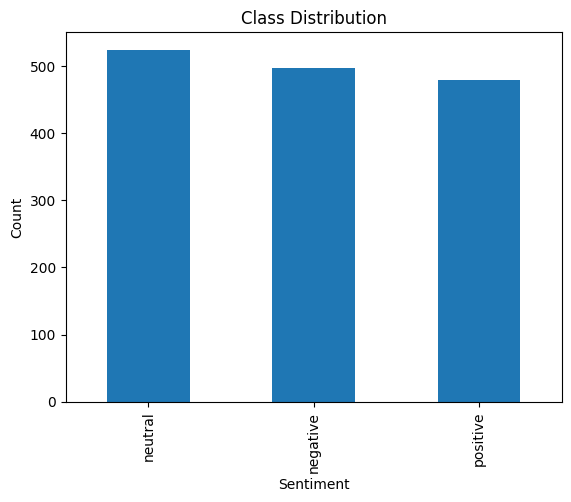

In [80]:
# Class distribution
print(df['sentiment_label'].value_counts())

# Visualize class distribution
import matplotlib.pyplot as plt
df['sentiment_label'].value_counts().plot(kind='bar')

plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

Why Dataset Understanding is Important?

Before building an NLP model, we must understand:

- How much data is available
- What the target classes are
- Whether the dataset is balanced
- Typical message length
- Examples of the text data

This helps in selecting:

- Proper preprocessing steps
- Suitable vectorization techniques
- Appropriate deep learning sequence length for models like RNN/LSTM

Task 2: Text Preprocessing

In [81]:
!pip3 install nltk
import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')

# load dataset
df = pd.read_csv(r"C:\Users\sriva\Downloads\ai_project_synthetic_datasets-20260505T144938Z-3-001\ai_project_synthetic_datasets\part_3_nlp_sequence_modeling\customer_support_text_classification.csv")  

# Display sample data
print(df.head())

  ticket_id channel                                   customer_message  \
0  TKT00001    chat  I need information about the payment process. ...   
1  TKT00002   phone      I need information about the payment process.   
2  TKT00003   email  The refund process was fast and convenient. I ...   
3  TKT00004  social  My refund is still pending and this experience...   
4  TKT00005    chat   Please tell me how to update my account details.   

  sentiment_label  word_count  urgent_flag  
0         neutral          18            1  
1         neutral           7            0  
2        positive          12            0  
3        negative          15            1  
4         neutral           9            0  


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sriva\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sriva\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [82]:
# Lowercasing
df['clean_text'] = df['customer_message'].str.lower()

# Remove special characters and symbols
def remove_special_characters(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['clean_text'] = df['clean_text'].apply(remove_special_characters)

# Tokenization
nltk.download('punkt_tab')
df['tokens'] = df['clean_text'].apply(word_tokenize)

# View sample tokens
print(df['tokens'].head())

0    [i, need, information, about, the, payment, pr...
1    [i, need, information, about, the, payment, pr...
2    [the, refund, process, was, fast, and, conveni...
3    [my, refund, is, still, pending, and, this, ex...
4    [please, tell, me, how, to, update, my, accoun...
Name: tokens, dtype: object


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\sriva\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [83]:
# Remove stop words
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df['tokens'] = df['tokens'].apply(remove_stopwords)

# Join tokens back into text
df['processed_text'] = df['tokens'].apply(lambda x: " ".join(x))

print(df[['customer_message', 'processed_text']].head())
df

                                    customer_message  \
0  I need information about the payment process. ...   
1      I need information about the payment process.   
2  The refund process was fast and convenient. I ...   
3  My refund is still pending and this experience...   
4   Please tell me how to update my account details.   

                                      processed_text  
0  need information payment process ticket number...  
1                   need information payment process  
2  refund process fast convenient appreciate quic...  
3  refund still pending experience frustrating ti...  
4                 please tell update account details  


,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag,clean_text,tokens,processed_text
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1,i need information about the payment process m...,"[need, information, payment, process, ticket, ...",need information payment process ticket number...
1,TKT00002,phone,I need information about the payment process.,neutral,7,0,i need information about the payment process,"[need, information, payment, process]",need information payment process
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0,the refund process was fast and convenient i a...,"[refund, process, fast, convenient, appreciate...",refund process fast convenient appreciate quic...
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1,my refund is still pending and this experience...,"[refund, still, pending, experience, frustrati...",refund still pending experience frustrating ti...
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0,please tell me how to update my account details,"[please, tell, update, account, details]",please tell update account details
...,...,...,...,...,...,...,...,...,...
1495,TKT01496,app,The refund process was fast and convenient. My...,positive,12,0,the refund process was fast and convenient my ...,"[refund, process, fast, convenient, ticket, nu...",refund process fast convenient ticket number
1496,TKT01497,social,Can you share the status of my service plan re...,neutral,15,0,can you share the status of my service plan re...,"[share, status, service, plan, request, ticket...",share status service plan request ticket number
1497,TKT01498,email,I need help finding the invoice for my last or...,neutral,10,0,i need help finding the invoice for my last order,"[need, help, finding, invoice, last, order]",need help finding invoice last order
1498,TKT01499,phone,The refund process was fast and convenient.,positive,7,0,the refund process was fast and convenient,"[refund, process, fast, convenient]",refund process fast convenient


In [84]:
# Sequence Preparation for Deep Learning Models
# For RNN/LSTM models, text must be converted into numerical sequences.
# Tokenization and padding are common steps in this process.
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['processed_text'])

sequences = tokenizer.texts_to_sequences(df['processed_text'])

# Padding / Truncating Sequences
# Deep learning models require all sequences to have the same length.
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 20

X_padded = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print(X_padded.shape)


(1500, 20)


Task 3: Text Vectorization


In [85]:
# Method 4: Tokenizer-Based Sequences
# import tokenizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Create tokenizer and fit on processed text
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['processed_text'])

# Convert text to sequences
sequences = tokenizer.texts_to_sequences(df['processed_text'])

print(sequences[:3])



[[14, 104, 64, 18, 1, 2, 3, 4, 5, 6], [14, 104, 64, 18], [13, 18, 37, 38, 15, 16, 9]]


In [86]:
# Padding Sequences
max_length = 20

X_padded = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post'
)

print(X_padded.shape)

(1500, 20)


Task 4: Baseline Model

In this task, we will build a simple NLP baseline model using:

- TF-IDF Vectorization
- Logistic Regression

This is a strong and commonly used baseline for text classification problems.

Why this baseline model?

TF-IDF:
- Converts text into numerical vectors
- Highlights important words

Logistic Regression:
- Works very well for text classification
- Fast and easy to interpret
- Performs strongly on sentiment datasets

In [109]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
# Load dataset
df = pd.read_csv(r"C:\Users\sriva\Downloads\ai_project_synthetic_datasets-20260505T144938Z-3-001\ai_project_synthetic_datasets\part_3_nlp_sequence_modeling\customer_support_text_classification.csv")
 
# Using preprocessed text for modeling
X = df['customer_message']
y = df['sentiment_label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Train Logistic Regression model
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)
# Predict on test data
y_pred = model.predict(X_test_tfidf)

# Show sample predictions
sample_df = pd.DataFrame({
    'Customer Message': X_test.values[:10],
    'Actual Label': y_test.values[:10],
    'Predicted Label': y_pred[:10]
})

print(sample_df)


# Evaluate model
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Classification Report
print(classification_report(y_test, y_pred))
df

                                    Customer Message Actual Label  \
0  I like the new payment and it is easy to use. ...     positive   
1  Great service and clear communication from the...     positive   
2  My refund is still pending and this experience...     negative   
3   The app crashes whenever I try to use analytics.     negative   
4  The response from the team was helpful and pro...     positive   
5  Can someone explain the difference between the...      neutral   
6   I like the new video call and it is easy to use.     positive   
7  I like the new report download and it is easy ...     positive   
8  Can someone explain the difference between the...      neutral   
9  I want to understand the warranty terms for th...      neutral   

  Predicted Label  
0        positive  
1        positive  
2        negative  
3        negative  
4        positive  
5         neutral  
6        positive  
7        positive  
8         neutral  
9         neutral  
Accuracy: 1.0
      

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0
...,...,...,...,...,...,...
1495,TKT01496,app,The refund process was fast and convenient. My...,positive,12,0
1496,TKT01497,social,Can you share the status of my service plan re...,neutral,15,0
1497,TKT01498,email,I need help finding the invoice for my last or...,neutral,10,0
1498,TKT01499,phone,The refund process was fast and convenient.,positive,7,0


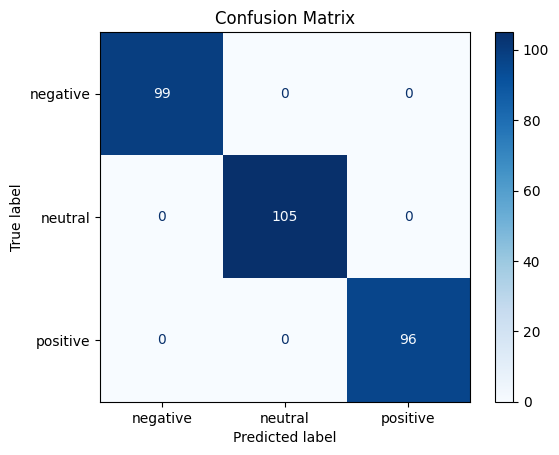

In [88]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

Task 5: Sequence Model or Conceptual Architecture

For this task, we will build a simple LSTM (Long Short-Term Memory) sequence model.

LSTM is a type of recurrent neural network (RNN) designed for sequential data like:

- Text
- Speech
- Time-series data

Unlike traditional NLP models, LSTM understands:

- Word order
- Context
- Sequence relationships

This makes it very useful for NLP tasks such as sentiment classification.

LSTM Model Architecture

Input Text
   ->
Tokenizer
   ->
Integer Sequences
   ->
Padding
   ->
Embedding Layer
   ->
LSTM Layer
   ->
Dense Output Layer
   ->
Prediction

Customer support messages often depend on context. Therefore LSTM is best suited for this dataset

Example:

“The service was good”
“The service was not good”

Both sentences contain the word “good”, but the meanings are different.

LSTM processes words sequentially, helping the model understand context better.

In [94]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Load dataset
df = pd.read_csv(r"C:\Users\sriva\Downloads\ai_project_synthetic_datasets-20260505T144938Z-3-001\ai_project_synthetic_datasets\part_3_nlp_sequence_modeling\customer_support_text_classification.csv")


# Prepare input and target
X = df['customer_message']
y = df['sentiment_label']

# Encode target labels
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print(encoder.classes_)

['negative' 'neutral' 'positive']


In [106]:
# Tokenization
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

vocab_size = 5000
max_length = 20


tokenizer = Tokenizer(num_words=vocab_size)

tokenizer.fit_on_texts(X)

sequences = tokenizer.texts_to_sequences(X)

# Padding Sequences
max_length = 20

X_padded = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_padded,
    y_encoded,
    test_size=0.2,
    random_state=42
)
# Build LSTM model
model = Sequential()
# Embedding layer
model.add(Embedding(
    input_dim=vocab_size,
    output_dim=128,
    input_shape=(max_length,)
))

# LSTM layer
model.add(LSTM(64))
# Embedding Layer
model.add(Embedding(
    input_dim=vocab_size,
    output_dim=128,
    input_length=max_length
))


# Output Layer
model.add(Dense(3, activation='softmax'))
# Compile model
model.compile(
    loss='sparse_categorical_crossentropy', # loss function for multi-class classification
    optimizer='adam',
    metrics=['accuracy']
)
model.summary()


print("Test Accuracy:", accuracy)

c:\Users\sriva\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\sriva\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ (None, 20, 128)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_12 (Embedding)        │ (None, 64, 128)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64, 3)          │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,795 (5.07 MB)

 Trainable params: 1,329,795 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

Test Accuracy: 1.0


In [105]:
LabelEncoder()
# Train the model
history = model.fit(
    X_padded,
    y_encoded,
    epochs=5,
    batch_size=32,
    validation_split=0.2

)
# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)


Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 8.6367e-05 - val_accuracy: 1.0000 - val_loss: 7.9417e-05
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 1.0000 - loss: 8.0188e-05 - val_accuracy: 1.0000 - val_loss: 7.3828e-05
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 1.0000 - loss: 7.4697e-05 - val_accuracy: 1.0000 - val_loss: 6.8860e-05
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 1.0000 - loss: 6.9763e-05 - val_accuracy: 1.0000 - val_loss: 6.4419e-05
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 1.0000 - loss: 6.5344e-05 - val_accuracy: 1.0000 - val_loss: 6.0391e-05
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 5.9224e-05 


array([[  4,  29, 136, ...,  14,   0,   0],
       [  4,  29, 136, ...,   0,   0,   0],
       [  1,  28,  33, ...,   0,   0,   0],
       ...,
       [  4,  29,  54, ...,   0,   0,   0],
       [  1,  28,  33, ...,   0,   0,   0],
       [ 74,   2,  75, ...,   0,   0,   0]], shape=(1500, 20), dtype=int32)

Task 6: Attention and Transformer Reflection
1. Why RNNs Struggle with Long-Term Dependencies

Recurrent Neural Networks (RNNs) process text one word at a time while passing information from previous steps through a hidden state.

However, standard RNNs struggle to remember information from words that appeared much earlier in a sequence.
For example:

“The customer who ordered the laptop last month is not happy.”

To correctly understand the sentiment, the model may need to remember important earlier words like: “customer” “ordered” “not”

As sequences become longer, early information gradually weakens during training. This problem is called the vanishing gradient problem.

As a result: 
- Important context is forgotten
- Long sentences become difficult to understand
- Performance decreases on long text sequences


2. How LSTMs Help with Memory

LSTM (Long Short-Term Memory) networks were designed to solve the memory limitations of standard RNNs.

LSTMs include special components called:

- Forget gate
- Input gate
- Output gate

These gates control:
- What information should be remembered
- What information should be discarded

This allows the network to preserve important context over longer sequences.
For example:
Sentence:
“The service was not good.”

An LSTM can remember the word:

"not"

while processing:

"good"

This helps the model understand the correct negative sentiment.

Because of this memory mechanism, LSTMs perform much better than standard RNNs on NLP tasks involving long or complex sequences.

3. What Attention Solves in Sequence-to-Sequence Tasks

In sequence-to-sequence tasks such as:

- Machine translation
- Text summarization
- Chatbots

traditional RNN/LSTM models try to compress the entire input sentence into a single fixed-size vector.

This becomes difficult for long sentences because important details may be lost.

Attention mechanisms solve this problem by allowing the model to focus on the most relevant words while generating each output word.

For example: input sentence:
“The movie was boring but the ending was amazing.”

When predicting the word related to sentiment about the ending, attention focuses more on: "amazing" instead of unrelated earlier words.

Attention improves:

- Context understanding
- Long-sequence handling
- Translation quality
- Sequence generation performance

4. Why Transformers are Important in Modern NLP and Generative AI

Transformers are advanced deep learning architectures built primarily around the attention mechanism.

Unlike RNNs and LSTMs, transformers process all words in parallel instead of one word at a time.

This provides several advantages:

- Faster training
- Better handling of long-range dependencies
- Improved scalability
- Stronger contextual understanding

Transformers use self-attention, which allows every word in a sentence to interact with every other word. For example:
Sentence: “The bank near the river was flooded.”

Self-attention helps determine whether “bank” refers to:

- a financial institution
or
- the side of a river

based on surrounding words.

Transformers are the foundation of modern NLP and Generative AI systems, including:

- OpenAI’s GPT models
- Google BERT
- Translation systems
- AI chatbots
- Text summarization tools
- Code generation systems

They power applications such as:

- ChatGPT
- AI assistants
- Content generation
- Question answering
- Conversational AI

Because of their ability to understand context and generate human-like text, transformers have become the dominant architecture in modern NLP.